# Does Paid Traffic Cause Higher Purchase Conversion?

**Question**: At the Google Merchandise Store, sessions arriving from paid campaigns convert at a different rate than organic/direct sessions. Is that difference *caused* by the campaigns, or do campaigns simply capture users who were going to convert anyway (selection effect)?

- **Treatment** — `is_paid`: session had a paid traffic medium (`cpc`/`cpm`/`ppc`/`paid`)
- **Outcome** — `converted`: session contained a `purchase` event
- **Confounders** — `device_category`, `geo_country` (top-10 + other), `is_new_user`

> Methodology demonstration, not a business finding: the GA4 sample dataset is obfuscated for privacy (many source/geo values are `<Other>`/NULL), and this notebook runs against however many daily shards have been staged so far.

## ***Import Libraries***

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone

# BigQuery
from google.cloud import bigquery

# Causal Inference
from dowhy import CausalModel

## ***Config***

In [2]:
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Pipeline configuration (kept in sync with analysis/causal_model.py)
PROJECT = os.environ.get("GCP_PROJECT_ID", "campaign-attribution-502801")
SESSIONS_TABLE = "dbt_campaign_attribution_marts.fct_sessions"
RESULTS_DATASET = "analysis"
RESULTS_TABLE = "causal_estimates"
TOP_N_COUNTRIES = 10

In [4]:
# Configure plotting
plt.rcParams['figure.figsize'] = (8, 3.5)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300

## ***Data Loading***

In [5]:
# Connect to BigQuery
client = bigquery.Client(project=PROJECT)
print(f"Connected to BigQuery project: {PROJECT}")

Connected to BigQuery project: campaign-attribution-502801


In [6]:
# Load the session-level mart
query = f'''
    select
        is_paid,
        converted,
        device_category,
        geo_country,
        is_new_user,
        session_date
    from `{PROJECT}.{SESSIONS_TABLE}`
'''
df = client.query(query).to_dataframe()
print(f"Loaded {SESSIONS_TABLE}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date range: {df['session_date'].min()} → {df['session_date'].max()}")

Loaded dbt_campaign_attribution_marts.fct_sessions
Shape: 6351 rows × 6 columns
Date range: 2020-11-01 → 2020-11-02


In [7]:
# Display first few rows
print(df.head())

   is_paid  converted device_category      geo_country  is_new_user  \
0    False      False         desktop           Sweden        False   
1    False      False         desktop           Turkey        False   
2    False      False         desktop  North Macedonia        False   
3    False      False         desktop           Canada        False   
4    False      False         desktop      South Korea        False   

  session_date  
0   2020-11-02  
1   2020-11-02  
2   2020-11-02  
3   2020-11-02  
4   2020-11-01  


In [8]:
# Check for missing values (NULL device/geo values are expected — obfuscated dataset)
missing_count = df.isnull().sum().sum()
if missing_count == 0:
    print("No missing values found")
else:
    print(df.isnull().sum())

No missing values found


In [9]:
# Treatment and outcome distribution
paid_counts = df['is_paid'].value_counts()
converted_counts = df['converted'].value_counts()
print(f"Class Distribution:")
print(f"Organic/direct (False): {paid_counts[False]} ({paid_counts[False]/len(df)*100:.2f}%)")
print(f"Paid (True):            {paid_counts[True]} ({paid_counts[True]/len(df)*100:.2f}%)")
print(f"Imbalance Ratio: {paid_counts[False]/paid_counts[True]:.2f}:1")
print(f"Converted sessions: {converted_counts.get(True, 0)} ({converted_counts.get(True, 0)/len(df)*100:.2f}%)")

Class Distribution:
Organic/direct (False): 6067 (95.53%)
Paid (True):            284 (4.47%)
Imbalance Ratio: 21.36:1
Converted sessions: 53 (0.83%)


## ***Data Preprocessing***

In [10]:
# Encode treatment, outcome, and boolean confounder as integers
model_df = pd.DataFrame({
    'is_paid': df['is_paid'].astype(int),
    'converted': df['converted'].astype(int),
    'is_new_user': df['is_new_user'].astype(int),
})
print(f"Encoded is_paid, converted, is_new_user")

Encoded is_paid, converted, is_new_user


In [11]:
# One-hot encode device category
device_dummies = pd.get_dummies(df['device_category'].fillna('unknown'), prefix='device', dtype=int)
print(f"Device categories: {list(device_dummies.columns)}")

Device categories: ['device_desktop', 'device_mobile', 'device_tablet']


In [12]:
# Group countries to top-N + other, then one-hot encode
top_countries = df['geo_country'].value_counts().head(TOP_N_COUNTRIES).index
country_grouped = df['geo_country'].where(df['geo_country'].isin(top_countries), 'other_country')
country_dummies = pd.get_dummies(country_grouped, prefix='geo', dtype=int)
# Column names must be valid identifiers for dowhy's formula handling
country_dummies.columns = [c.replace(' ', '_').replace('<', '').replace('>', '') for c in country_dummies.columns]
print(f"Country columns: {list(country_dummies.columns)}")

Country columns: ['geo_Canada', 'geo_China', 'geo_France', 'geo_Germany', 'geo_India', 'geo_Japan', 'geo_Spain', 'geo_Taiwan', 'geo_United_Kingdom', 'geo_United_States', 'geo_other_country']


In [13]:
# Assemble the final model dataframe
model_df = pd.concat([model_df, device_dummies, country_dummies], axis=1)
confounders = ['is_new_user'] + list(device_dummies.columns) + list(country_dummies.columns)
print(f"Final Feature Set")
print(f"Total confounders: {len(confounders)}")
print(f"Model dataframe shape: {model_df.shape}")

Final Feature Set
Total confounders: 15
Model dataframe shape: (6351, 17)


## ***Naive Correlation (No Adjustment)***

In [14]:
# Conversion rate by treatment group — what a dashboard with no causal thinking reports
group_rates = model_df.groupby('is_paid')['converted'].agg(sessions='size', conversions='sum', conversion_rate='mean')
print(group_rates)

naive_difference = float(group_rates.loc[1, 'conversion_rate'] - group_rates.loc[0, 'conversion_rate'])
print(f"Naive difference: {naive_difference:+.4f} ({naive_difference*100:+.2f} percentage points)")

         sessions  conversions  conversion_rate
is_paid                                        
0            6067           51         0.008406
1             284            2         0.007042
Naive difference: -0.0014 (-0.14 percentage points)


## ***Causal Model (DoWhy)***

Causal graph assumption: device, country, and new-vs-returning status influence **both** which channel a user arrives through and their propensity to buy — classic confounding. Conditioning on them (the backdoor criterion) isolates the treatment effect, under the usual caveat that *unobserved* confounders (e.g. purchase intent itself) remain uncontrolled.

In [15]:
# Build the causal model and identify the estimand
causal_model = CausalModel(
    data=model_df,
    treatment='is_paid',
    outcome='converted',
    common_causes=confounders
)
estimand = causal_model.identify_effect(proceed_when_unidentifiable=True)
print("Estimand identified via backdoor criterion")

Estimand identified via backdoor criterion


In [16]:
# Dictionary to store estimation results
causal_results = {}

### ***Propensity Score Matching***

In [17]:
# Estimate the ATE via propensity score matching
psm_estimate = causal_model.estimate_effect(
    estimand,
    method_name='backdoor.propensity_score_matching',
    target_units='ate'
)
psm_ate = float(psm_estimate.value)

In [18]:
causal_results['propensity_score_matching'] = {
    'ate': psm_ate,
    'naive_difference': naive_difference,
}
print(f"ATE: {psm_ate:+.4f} ({psm_ate*100:+.2f} pp)")
print(f"Naive difference, for reference: {naive_difference:+.4f} ({naive_difference*100:+.2f} pp)")

ATE: -0.0077 (-0.77 pp)
Naive difference, for reference: -0.0014 (-0.14 pp)


### ***Propensity Score Weighting***

In [19]:
# Estimate the ATE via inverse propensity weighting (robustness check)
psw_estimate = causal_model.estimate_effect(
    estimand,
    method_name='backdoor.propensity_score_weighting',
    target_units='ate'
)
psw_ate = float(psw_estimate.value)

In [20]:
causal_results['propensity_score_weighting'] = {
    'ate': psw_ate,
    'naive_difference': naive_difference,
}
print(f"ATE: {psw_ate:+.4f} ({psw_ate*100:+.2f} pp)")
print(f"Naive difference, for reference: {naive_difference:+.4f} ({naive_difference*100:+.2f} pp)")

ATE: -0.0012 (-0.12 pp)
Naive difference, for reference: -0.0014 (-0.14 pp)


## ***Refutation Test***

In [21]:
# Placebo test — replace the treatment with noise; the effect should collapse toward zero
placebo_refutation = causal_model.refute_estimate(
    estimand,
    psw_estimate,
    method_name='placebo_treatment_refuter',
    placebo_type='permute',
    num_simulations=5
)
placebo_effect = float(placebo_refutation.new_effect)
print(f"Placebo-treatment effect: {placebo_effect:+.5f} (should be ≈ 0)")

Placebo-treatment effect: -0.00077 (should be ≈ 0)


## ***Results Visualization***

Visualization saved as 'causal_estimates_comparison.png'


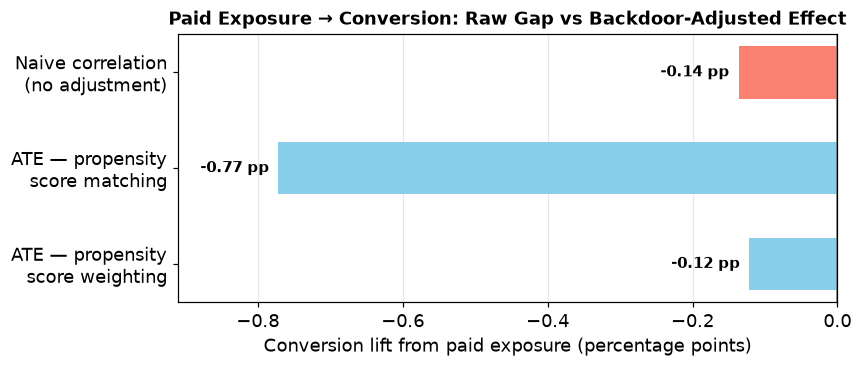

In [22]:
# Compare the naive correlation against the adjusted estimates
estimates = [
    ('Naive correlation\n(no adjustment)', naive_difference * 100, 'salmon'),
    ('ATE — propensity\nscore matching', psm_ate * 100, 'skyblue'),
    ('ATE — propensity\nscore weighting', psw_ate * 100, 'skyblue'),
]
labels = [e[0] for e in estimates][::-1]
values = [e[1] for e in estimates][::-1]
colors = [e[2] for e in estimates][::-1]

fig, ax = plt.subplots()
bars = ax.barh(labels, values, color=colors, height=0.55)
ax.bar_label(bars, fmt='%+.2f pp', padding=6, fontsize=10, fontweight='bold')
ax.axvline(0, color='gray', linewidth=1)
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.set_xlabel('Conversion lift from paid exposure (percentage points)')
ax.set_title('Paid Exposure → Conversion: Raw Gap vs Backdoor-Adjusted Effect', fontweight='bold', fontsize=12)
ax.margins(x=0.18)
plt.tight_layout()
plt.savefig('causal_estimates_comparison.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'causal_estimates_comparison.png'")
plt.show()

## ***Persist Results***

In [23]:
# Assemble the results dataframe (one row per estimation method)
run_at = datetime.now(timezone.utc)
results_rows = []
for method, result in causal_results.items():
    results_rows.append({
        'method': method,
        'ate': result['ate'],
        'run_at': run_at,
        'naive_difference': result['naive_difference'],
        'n_sessions': len(df),
        'n_paid': int(model_df['is_paid'].sum()),
        'n_converted': int(model_df['converted'].sum()),
        'data_start': df['session_date'].min(),
        'data_end': df['session_date'].max(),
    })
results_df = pd.DataFrame(results_rows)
print(results_df[['method', 'ate', 'naive_difference', 'n_sessions', 'n_paid']])

                       method       ate  naive_difference  n_sessions  n_paid
0   propensity_score_matching -0.007715         -0.001364        6351     284
1  propensity_score_weighting -0.001216         -0.001364        6351     284


In [24]:
# Write to BigQuery via load job (BigQuery Sandbox forbids DML)
# Downstream: dbt view fct_causal_estimates, MetricFlow metric causal_lift_estimate, dashboard
dataset_ref = bigquery.Dataset(f"{PROJECT}.{RESULTS_DATASET}")
dataset_ref.location = 'US'
client.create_dataset(dataset_ref, exists_ok=True)

table_id = f"{PROJECT}.{RESULTS_DATASET}.{RESULTS_TABLE}"
load_job = client.load_table_from_dataframe(
    results_df,
    table_id,
    job_config=bigquery.LoadJobConfig(write_disposition='WRITE_TRUNCATE'),
)
load_job.result()
print(f"Wrote {len(results_df)} rows to {table_id}")

Wrote 2 rows to campaign-attribution-502801.analysis.causal_estimates


## ***Reading the Result***

- **If the ATE is smaller than the naive difference**, part of the raw gap is selection: paid campaigns reach users (devices, geographies, returning visitors) who convert more anyway. The difference between the two bars is the amount a naive dashboard would over-credit the campaigns.
- **If the ATE is close to the naive difference**, the observed confounders explain little of the gap on this sample.
- The placebo effect near zero says the estimator isn't manufacturing signal, but it cannot rule out **unobserved** confounding (e.g. purchase intent). With obfuscated demo data and a small staged window, widen the extract (more daily shards) before reading anything into the point estimates.

**Next steps** — validate against a synthetic dataset with a known ground-truth effect; add an uplift model (scikit-uplift) for targeting on top of the average effect.